In [140]:
import numpy
import pandas
from matplotlib import pyplot
import seaborn
import keras

In [141]:
titanic = pandas.read_csv("../conjuntos/titanic.csv")

titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [142]:
titanic[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Cabin", "Embarked"]]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


<Axes: xlabel='Pclass', ylabel='Count'>

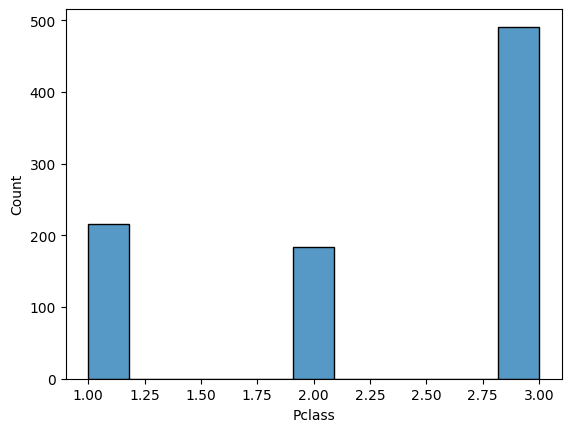

In [143]:
seaborn.histplot(x=titanic["Pclass"])

<Axes: xlabel='Pclass', ylabel='Count'>

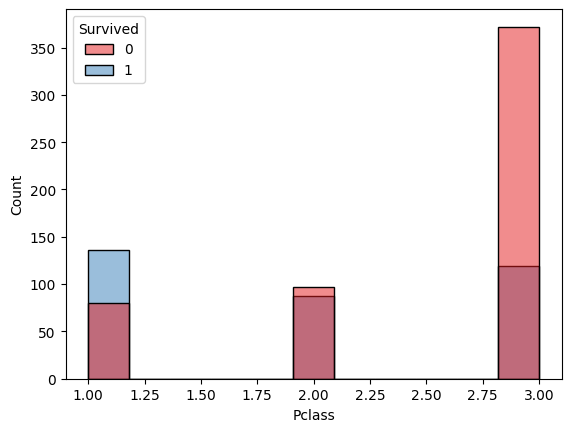

In [144]:
# Numérico vs Categoríco (X / B)
seaborn.histplot(x=titanic["Pclass"], hue=titanic["Survived"], palette="Set1")

In [145]:
# Supervivencia por clase del boleto
# SOBREVIVE : NO SOBREVIVE

# 1ra clase
# 1.6 : 1

# 2da clase
# 1 : 1.1

# 3ra clase
# 1 : 4

In [146]:
len(titanic[(titanic["Survived"] == 1) & (titanic["Pclass"] == 1)]) / len(titanic[(titanic["Survived"] == 0) & (titanic["Pclass"] == 1)])

1.7

In [147]:
len(titanic[(titanic["Survived"] == 0) & (titanic["Pclass"] == 2)]) / len(titanic[(titanic["Survived"] == 1) & (titanic["Pclass"] == 2)])

1.1149425287356323

In [148]:
len(titanic[(titanic["Survived"] == 0) & (titanic["Pclass"] == 3)]) / len(titanic[(titanic["Survived"] == 1) & (titanic["Pclass"] == 3)])

3.1260504201680672

In [149]:
# 1ra clase
# 1.7 : 1  (2.7)  63 : 37

# 2da clase
# 1 : 1.11 (2.11) 47 : 53

# 3ra clase
# 1 : 3.12 (4.12) 24 : 76

In [150]:
pandas.DataFrame({
    "NO SOBREVIVE": [37, 53, 76],
    "SOBREVIVE": [63, 47, 24],
}, index=["1ra", "2da", "3ra"])

,NO SOBREVIVE,SOBREVIVE
1ra,37,63
2da,53,47
3ra,76,24


In [151]:
titanic[["Pclass", "Survived"]].groupby(["Pclass", "Survived"]).size().unstack()

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [152]:
R1 = titanic[["Pclass", "Survived"]].groupby(["Pclass", "Survived"]).size().unstack()
R2 = (R1.divide(R1.sum(axis=1), axis=0) * 100).round(0)
R2

Survived,0,1
Pclass,,
1,37.0,63.0
2,53.0,47.0
3,76.0,24.0


<Axes: xlabel='Survived', ylabel='Pclass'>

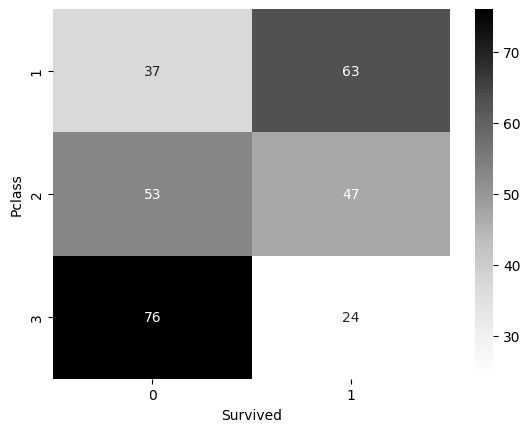

In [153]:
seaborn.heatmap(R2, cmap="Grays", annot=True)

In [154]:
titanic[["Sex"]].groupby("Sex").size()

Sex
female    314
male      577
dtype: int64

In [155]:
titanic["Age"].isna().sum() / len(titanic) * 100

np.float64(19.865319865319865)

<Axes: ylabel='Density'>

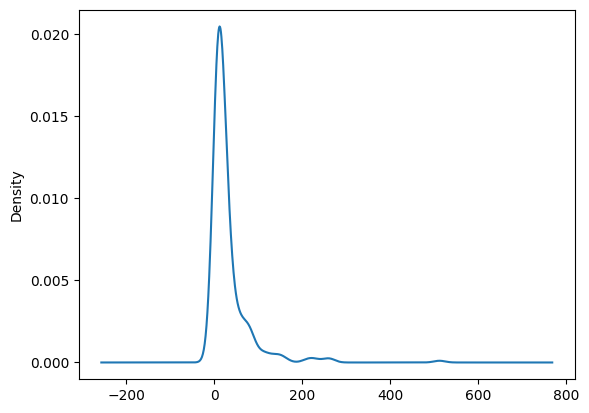

In [156]:
titanic["Fare"].plot.density()

<Axes: xlabel='Fare', ylabel='Density'>

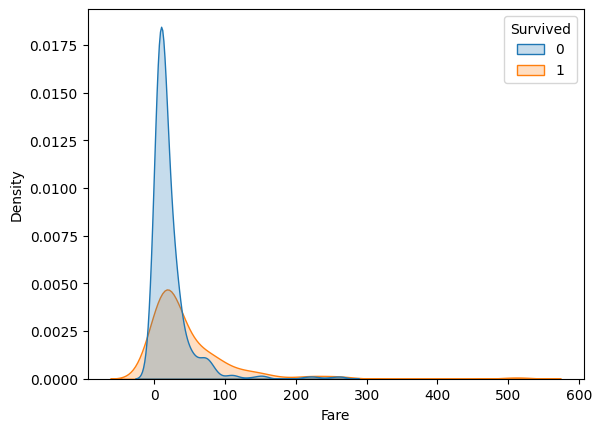

In [157]:
seaborn.kdeplot(x=titanic["Fare"], hue=titanic["Survived"], fill=True)

<Axes: >

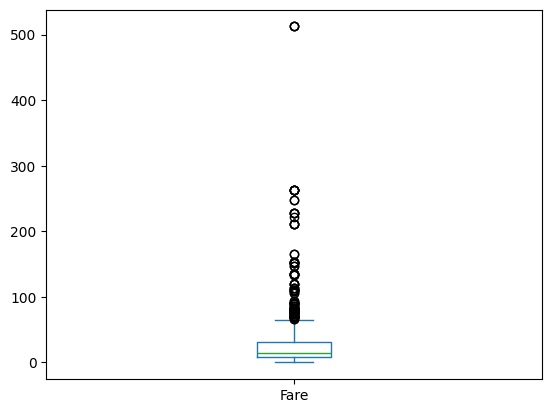

In [158]:
titanic["Fare"].plot.box()

In [159]:
titanic["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Density'>

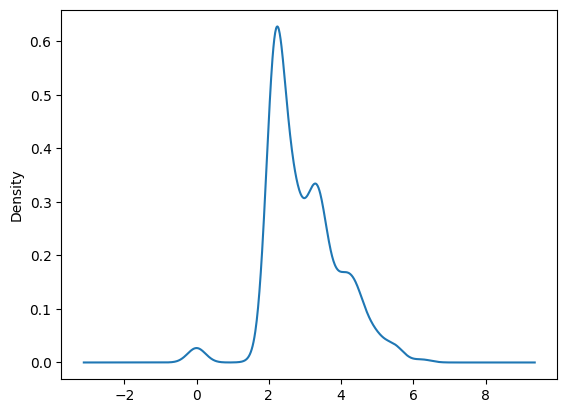

In [160]:
titanic["Fare"].apply(numpy.log1p).plot.density()

<Axes: xlabel='Fare', ylabel='Density'>

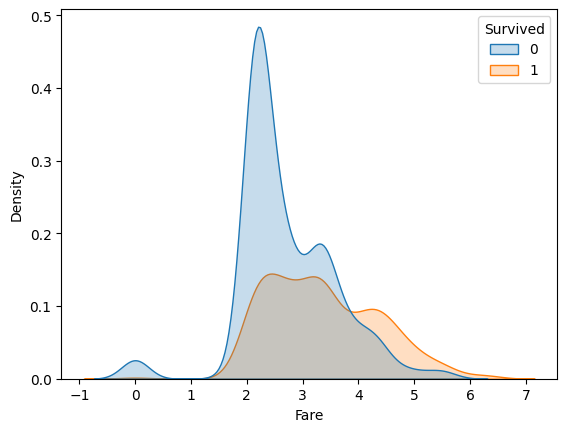

In [161]:
seaborn.kdeplot(x=titanic["Fare"].apply(numpy.log1p), hue=titanic["Survived"], fill=True)

<Axes: >

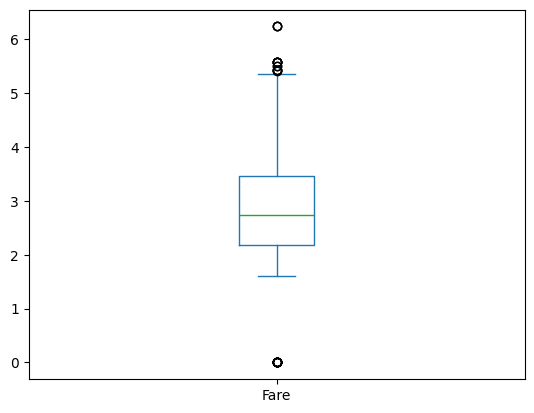

In [162]:
titanic["Fare"].apply(numpy.log1p).plot.box()

In [163]:
titanic[["Embarked"]].groupby("Embarked").size()

Embarked
C    168
Q     77
S    644
dtype: int64

In [164]:
titanic[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Cabin", "Embarked"]]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


In [165]:
# Numérico
c1 = titanic["Survived"] # Numérico

# Categórico -> Numérico
# One-Hot | Transformación directa (lógica)
# La primera clase aumenta la supervivencia
# La tercera clase disminuye la supervivencia
c2 = titanic["Pclass"].map({
    3: 1,
    2: 2,
    1: 3,
}) # Numérico | Categórico

# Categórico -> Numérico
# One-Hot | Transformación directa (lógica)
# Dummy 1: Mujer (female) 314
# Dummy 2: Hombre (male)  577 * base
c3 = (titanic["Sex"] == "female").astype(int) # Categórico (binario)
c3.name = "Sex_Female"

# Numérico
# Imputación por la mediana
# Otros tipos de imputaciones de datos faltantes:
# - Sustitución por Árboles de Decisión / Bosques Aleatorios
# - Sustitución por el promedio / mediana del clúster
# - Regresión de la edad con las otras características
c4 = titanic["Age"].fillna(titanic["Age"].median()) # Numérico

c5 = titanic["SibSp"] + titanic["Parch"] # Numérico
c5.name = "Family"

c6 = titanic["Fare"].apply(numpy.log1p) # Numérico
c6.name = "LN1P_Fare"

c7 = (~titanic["Cabin"].isna()).astype(int) # Categórico

# Categórico -> Numérico
# One-Hot | Transformación directa (lógica)
# Dummy 1: Southampton (S) 644 * base
# Dummy 2: Cherburg    (C)  77
# Dummy 3: Queenstown  (Q) 168
c8 = (titanic["Embarked"] == "C").astype(int) # Categórico
c8.name = "Embarked_C"
c9 = (titanic["Embarked"] == "Q").astype(int) # Categórico
c9.name = "Embarked_Q"

C = pandas.DataFrame([c1, c2, c3, c4, c5, c6, c7, c8, c9]).T
C

,Survived,Pclass,Sex_Female,Age,Family,LN1P_Fare,Cabin,Embarked_C,Embarked_Q
0,0.0,1.0,0.0,22.0,1.0,2.110213,0.0,0.0,0.0
1,1.0,3.0,1.0,38.0,1.0,4.280593,1.0,1.0,0.0
2,1.0,1.0,1.0,26.0,0.0,2.188856,0.0,0.0,0.0
3,1.0,3.0,1.0,35.0,1.0,3.990834,1.0,0.0,0.0
4,0.0,1.0,0.0,35.0,0.0,2.202765,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
886,0.0,2.0,0.0,27.0,0.0,2.639057,0.0,0.0,0.0
887,1.0,3.0,1.0,19.0,0.0,3.433987,1.0,0.0,0.0
888,0.0,1.0,1.0,28.0,3.0,3.196630,0.0,0.0,0.0
889,1.0,3.0,0.0,26.0,0.0,3.433987,1.0,1.0,0.0


In [166]:
numpy.log1p(24)

np.float64(3.2188758248682006)

In [167]:
numpy.log(1 + 0)

np.float64(0.0)

In [168]:
X = C[["Pclass", "Sex_Female", "Age", "Family", "Cabin", "LN1P_Fare", "Embarked_C", "Embarked_Q"]]

X

,Pclass,Sex_Female,Age,Family,Cabin,LN1P_Fare,Embarked_C,Embarked_Q
0,1.0,0.0,22.0,1.0,0.0,2.110213,0.0,0.0
1,3.0,1.0,38.0,1.0,1.0,4.280593,1.0,0.0
2,1.0,1.0,26.0,0.0,0.0,2.188856,0.0,0.0
3,3.0,1.0,35.0,1.0,1.0,3.990834,0.0,0.0
4,1.0,0.0,35.0,0.0,0.0,2.202765,0.0,0.0
...,...,...,...,...,...,...,...,...
886,2.0,0.0,27.0,0.0,0.0,2.639057,0.0,0.0
887,3.0,1.0,19.0,0.0,1.0,3.433987,0.0,0.0
888,1.0,1.0,28.0,3.0,0.0,3.196630,0.0,0.0
889,3.0,0.0,26.0,0.0,1.0,3.433987,1.0,0.0


In [169]:
Y = C[["Survived"]]

Y

,Survived
0,0.0
1,1.0
2,1.0
3,1.0
4,0.0
...,...
886,0.0
887,1.0
888,0.0
889,1.0


## Red neuronal de 1x1 (Perceptrón logístico)

In [170]:
modelo = keras.Sequential([
    keras.Input(shape=(8,)), # 8 características en cada observación
    keras.layers.Dense(1, activation="sigmoid") # 1 respuesta binanria
])

modelo.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [171]:
modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [172]:
historial = modelo.fit(X, Y, epochs=500)

Epoch 1/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.3707 - loss: 9.1045 
Epoch 2/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step - accuracy: 0.3928 - loss: 8.0569
Epoch 3/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3676 - loss: 7.8592 
Epoch 4/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.3907 - loss: 7.0560
Epoch 5/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - accuracy: 0.3896 - loss: 6.4264
Epoch 6/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step - accuracy: 0.3943 - loss: 5.6929
Epoch 7/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - accuracy: 0.3649 - loss: 5.3903
Epoch 8/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - accuracy: 0.3755 - loss: 4.6921
Epoch 9/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step - accuracy: 0.3936 - loss: 3.7074
Epoch 10/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - accuracy: 0.3605 - loss: 3.4306
Epoch 11/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.3894 - loss: 2.7061
Epoch 12/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0

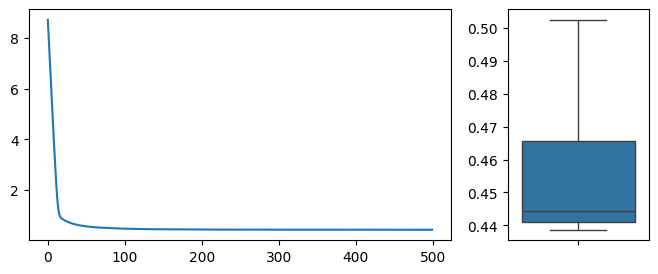

In [173]:
for metrica, valores in historial.history.items():
    if metrica == "loss":
        figure, axes = pyplot.subplots(1, 2, figsize=(8, 3), width_ratios=[3, 1])
        seaborn.lineplot(x=range(len(valores)), y=valores, ax=axes[0])
        seaborn.boxplot(y=valores, ax=axes[1], showfliers=False)

In [174]:
modelo.evaluate(X, Y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - accuracy: 0.8118 - loss: 0.4455


[0.4383174180984497, 0.8069584965705872]

In [175]:
modelo.save("nn2_1x1.keras")

In [176]:
modelo = keras.models.load_model("nn2_1x1.keras")

In [177]:
# Pclass	Sex_Female	Age	Family	Cabin	LN1P_Fare	Embarked_C	Embarked_Q

modelo.predict(numpy.array([
    [1.0, 0.0, 22.0, 1.0, 0.0, 2.110213, 0.0, 0.0], # 0
    [3.0, 1.0, 38.0, 1.0, 1.0, 4.280593, 1.0, 0.0], # 1
    [2, 0, 45, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 1, 45, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 0, 15, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 1, 15, 0, 0, numpy.log1p(25), 0, 1], # ?
]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[0.10807306],
       [0.94147736],
       [0.13445427],
       [0.697808  ],
       [0.36722755],
       [0.8961247 ]], dtype=float32)

## Red neuronal de 16x1 (tipo ReLU)

In [178]:
modelo = keras.Sequential([
    keras.Input(shape=(8,)), # 8 características en cada observación
    keras.layers.Dense(16, activation="relu"), # 16 neuronas oculas tipo ReLU
    keras.layers.Dense(1, activation="sigmoid") # 1 respuesta binanria
])

modelo.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [179]:
modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [180]:
historial = modelo.fit(X, Y, epochs=500)

Epoch 1/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.6185 - loss: 2.7861
Epoch 2/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6126 - loss: 1.4320 
Epoch 3/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.5920 - loss: 0.7418
Epoch 4/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - accuracy: 0.5807 - loss: 0.7225
Epoch 5/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - accuracy: 0.6521 - loss: 0.6538
Epoch 6/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - accuracy: 0.6301 - loss: 0.6676
Epoch 7/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.6451 - loss: 0.6543
Epoch 8/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6935 - loss: 0.6209 
Epoch 9/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.7142 - loss: 0.6020
Epoch 10/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.7424 - loss: 0.5814
Epoch 11/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step - accuracy: 0.7321 - loss: 0.5836
Epoch 12/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 

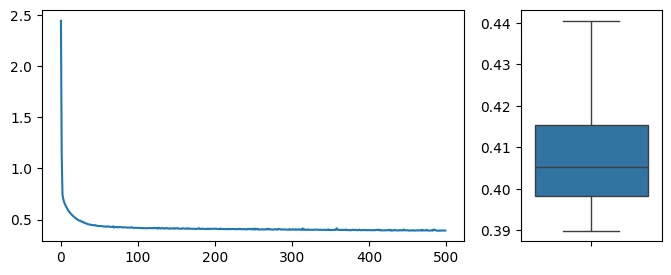

In [181]:
for metrica, valores in historial.history.items():
    if metrica == "loss":
        figure, axes = pyplot.subplots(1, 2, figsize=(8, 3), width_ratios=[3, 1])
        seaborn.lineplot(x=range(len(valores)), y=valores, ax=axes[0])
        seaborn.boxplot(y=valores, ax=axes[1], showfliers=False)

In [182]:
modelo.evaluate(X, Y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.8359 - loss: 0.4188


[0.39801377058029175, 0.8428731560707092]

In [183]:
modelo.save("nn2_16x1.keras")

In [184]:
modelo = keras.models.load_model("nn2_16x1.keras")

In [185]:
# Pclass	Sex_Female	Age	Family	Cabin	LN1P_Fare	Embarked_C	Embarked_Q

modelo.predict(numpy.array([
    [1.0, 0.0, 22.0, 1.0, 0.0, 2.110213, 0.0, 0.0], # 0
    [3.0, 1.0, 38.0, 1.0, 1.0, 4.280593, 1.0, 0.0], # 1
    [2, 0, 45, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 1, 45, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 0, 15, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 1, 15, 0, 0, numpy.log1p(25), 0, 1], # ?
]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[0.06169444],
       [0.93770313],
       [0.1120557 ],
       [0.70811135],
       [0.02710711],
       [0.7924167 ]], dtype=float32)

## Red neuronal de 16x8x4x1 (tipo ReLU)

In [211]:
modelo = keras.Sequential([
    keras.Input(shape=(8,)), # 8 características en cada observación [2, -1, -45, ...]
    keras.layers.Dense(16, activation="relu"), # 16 neuronas oculas tipo ReLU
    keras.layers.Dense(8, activation="relu"), # 8 neuronas oculas tipo ReLU
    keras.layers.Dense(4, activation="relu"), # 4 neuronas oculas tipo ReLU
    keras.layers.Dense(1, activation="sigmoid") # 1 respuesta binanria
])

modelo.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [212]:
modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [213]:
historial = modelo.fit(X, Y, epochs=500)

Epoch 1/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step - accuracy: 0.3924 - loss: 1.3218 
Epoch 2/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3762 - loss: 0.9431 
Epoch 3/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.3434 - loss: 0.8117
Epoch 4/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4068 - loss: 0.7175 
Epoch 5/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - accuracy: 0.4015 - loss: 0.6910
Epoch 6/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - accuracy: 0.6362 - loss: 0.6583
Epoch 7/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.6813 - loss: 0.6419
Epoch 8/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - accuracy: 0.7527 - loss: 0.6366
Epoch 9/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7498 - loss: 0.6269 
Epoch 10/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7643 - loss: 0.6047 
Epoch 11/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7803 - loss: 0.6065 
Epoch 12/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

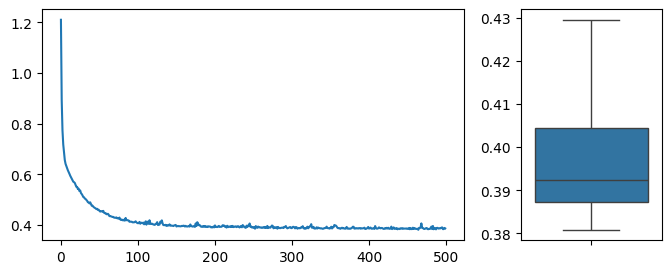

In [214]:
for metrica, valores in historial.history.items():
    if metrica == "loss":
        figure, axes = pyplot.subplots(1, 2, figsize=(8, 3), width_ratios=[3, 1])
        seaborn.lineplot(x=range(len(valores)), y=valores, ax=axes[0])
        seaborn.boxplot(y=valores, ax=axes[1], showfliers=False)

In [215]:
modelo.evaluate(X, Y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - accuracy: 0.8290 - loss: 0.4050


[0.3874070942401886, 0.8372614979743958]

In [216]:
modelo.save("nn2_16x8x4x1.keras")

In [217]:
modelo = keras.models.load_model("nn2_16x8x4x1.keras")

In [218]:
# Pclass	Sex_Female	Age	Family	Cabin	LN1P_Fare	Embarked_C	Embarked_Q

modelo.predict(numpy.array([
    [1.0, 0.0, 22.0, 1.0, 0.0, 2.110213, 0.0, 0.0], # 0
    [3.0, 1.0, 38.0, 1.0, 1.0, 4.280593, 1.0, 0.0], # 1
    [2, 0, 45, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 1, 45, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 0, 15, 0, 0, numpy.log1p(25), 0, 1], # ?
    [2, 1, 15, 0, 0, numpy.log1p(25), 0, 1], # ?
]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[0.11208929],
       [0.98677653],
       [0.1269281 ],
       [0.88885134],
       [0.13882211],
       [0.9992554 ]], dtype=float32)

> RECESO 9:07 a 9:22